# Test Day

**Date**: Monday 31/08/2026  
**Start & End Time**: 13.45-17.45  

Koen Gort  
Alesja Zorina


**Setting Up The oscilloscope and manually plucking the string**    
20ms/div, 50 mV  
peak voltage after manually plucking: ~100 mV  

When setting the trigger level, it would jump to 167mV, instead of our desired 50 mV. The solution was to set the scale level within the range of our max voltage. After adjusting this to 200 mV, the trigger level worked and we saw a sine graph when plucking it a single time ("with Single").

Username of scope: ShareUser  

Results of manual pluck:

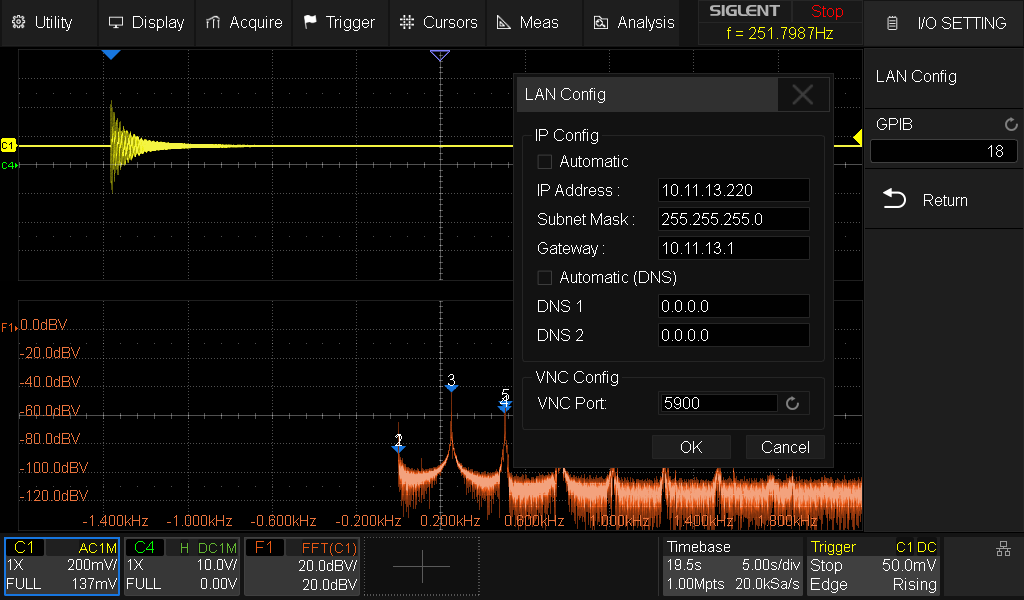

**Setting up the function generator**  

We set the function generator from CH1 to CH4 on the scope. Channel 4 was not working on the scope, so we switched to CH2.  
The following function generator settings were used:  
square wave  
Vpp = 1 V  
Frequency = Hz  

During the setup, for a long time no output from the string was visible on the scope. When plucking manually, a signal was given, and it propagated through the screen, but in a few seconds died out became a straight line again.  
We changed the frequency gradually from 1 kHz to 100 Hz to find the resonance frequency, while keeping the Vpp at 1 V.  
Afterwards we noticed the amplitude was low and changed the Vpp to 5V.  
Conclusion: highest amplitude and thus resonance frequency occurs at 130 Hz.

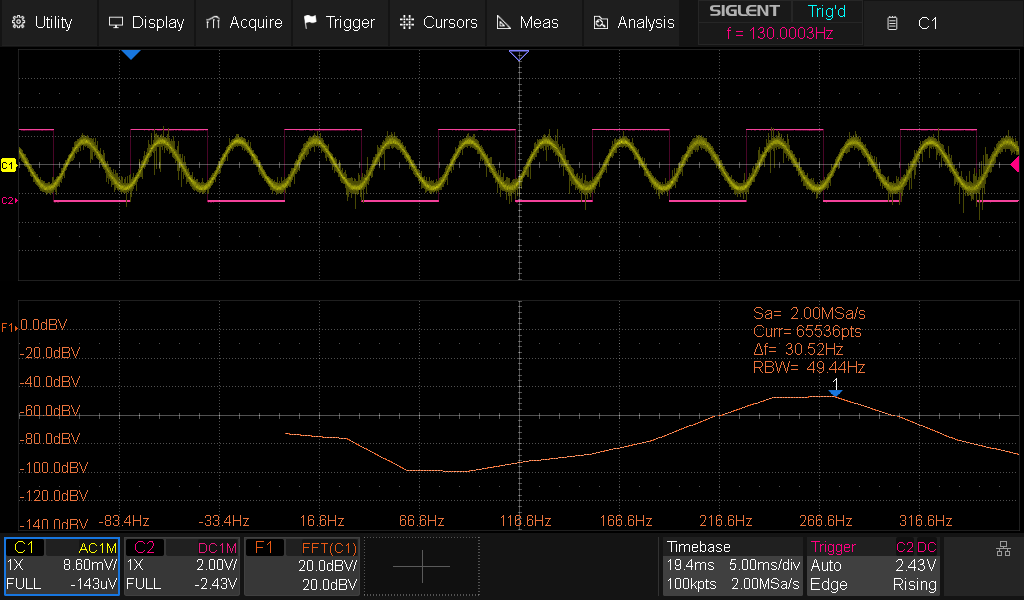

For 1.5 hours, the output sine from the wire was not showing properly on the scope. This took up a significant amount of time. The conclusion made by the assistant was that the function generator was faulty. 

**Wire-Length Dependent Frequency, experimental measurement**  
Start time: 16:47  
End time: 17.10  
Here we measured the resonance frequency at different lengths of the wire.  
Procedure:  
* set the wire length to 35 cm between the holders
* note this length
* decrease the length by 1 cm 
* find the resonance frequency by manually turning the knob on the function generator until the amplitude becomes maximal
* note this frequency
* continue until 28 cm

In [1]:
import numpy as np
import matplotlib.pyplot as plt

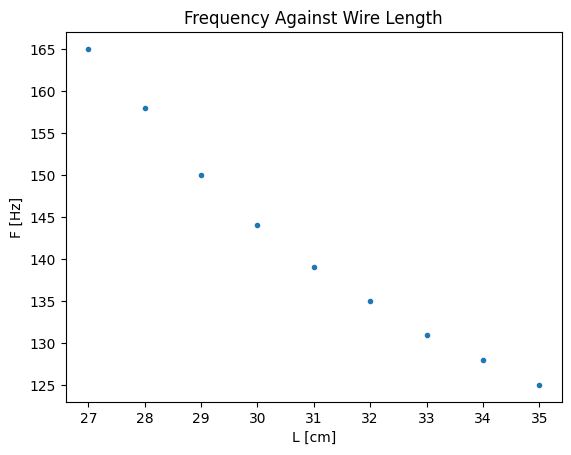

In [2]:
L_test = np.array([35,34,33,32,31,30,29,28,27]) #cm
Freq_test = np.array([125,128,131,135,139,144,150,158,165]) #Hz

L_err = 0.5 #cm

plt.figure()
plt.title("Frequency Against Wire Length")
plt.plot(L_test,Freq_test,".")
plt.xlabel("L [cm]")
plt.ylabel("F [Hz]")
plt.show()

**Voorlopige onderzoeksvraag**

"Hoe hangt de eigenfrequentie van een draad af van de spankracht bij een constante draadlengte?"


**Notes**

* When the mass is vibrating, the measurements shows some significant noise
* research question alternative: same question but for higher order frequency



# Measuring Day 1
**Date**: Monday 07/09/2026  
**Time**: 13.45-17.45


Research question: How much is the tension-dependance of the ground frequency in accordance with the theoretical relation at a constant wire length of 25 cm?  

*(NL: In hoeverre komt de experimenteel bepaalde afhankelijkheid van de grondfrequentie van de spankracht  overeen met het theoretische verband bij een constante draadlengte van 25 cm?)*

Hypothesis: The frequency is proportional to a power function of the tension, with the power coefficient equal to 0.5.  
Theory:  
$ f = \frac{n}{2L} \sqrt{\frac{T}{\mu}} $  
$T =\frac{m g r_m \sin(\theta_m)}{r_w \sin(\theta_w)}$  

Measuring setup:  
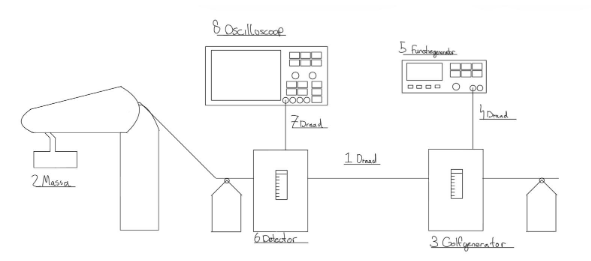

**Measuring Procedure**:  

- Set wire length at 25 cm
- Connect the oscilloscope and function generator
- Hang the first mass on the first arm length and measure the angle between the arm and vertical line going through the hanging mass.
- Find the groundfrequency by turning the knob on the function generator untill the amplitude stops rising. When the amplitude is at its maximum, you have found the ground frequency.  
note: start at a low frequency to prevent accidentally recording an overtone
- Repeat for all other arm lengths
- Place the next mass, then repeat the whole process for all masses and arm lengths. Add the masses in steps of **0.25 kg** from **0.5 kg** to **2 kg**
- make repeated measurements for extra accuracy

The following settings were used for the function generator:  
- square wave, 5 Vpp, No offset

In [3]:
#constants
g = 9.81 #m/s^2
#mu = #mass density of wire

#arm lengths of mass-support hold
r1 = 8.37e-2 #m
r2 = 12.02e-2 #m
r3 = 15.66e-2 #m
r4 = r3 + 3.78e-2 #m schuifmaat was niet lang genoeg

r_u = 0.5e-3 #m, uncertainty op schuifmaat

In [4]:
#makeshift masses (zakken grind)
#There are so many variables because the repeated masses are also make-shift and differ slightly

m_1=1.0473 #kg
m_2 = 0.4931 #kg
m_4 = 773.3e-3
m_5 = 1248.9e-3 #kg
m_6 = 1498.5e-3 #kg
m_7 = 1756.0e-3 #kg
m_8 = 2085.0e-3 #kg
m_9 = 270.9e-3 #kg

#masses for repeated measurements
m_1r = 492.2e-3 #kg
m_2r = 1046e-3 #kg
m_3r = 752.7e-3 #kg
m_4r = 1280.0e-3 #kg
m_5r = 1534.7e-3 #kg
m_6r = 2084.0e-3 #kg

#uncertainties
m_unc = 1e-4 / 2 #kg
theta_wire = np.deg2rad(90)
theta_u = np.deg2rad(2)

In [5]:
#WITHOUT FAULTY

#data
L = 25e-2   #m
L_u = 0.5e-2 #m
Freq = np.array([116,143,163,181,
                 127,112,93,
                 157,142,122,
                 197,183,157,
                 211,192,170,
                 211,184,
                 250,223,202,
                 126,112,97,
                 182,163,142,115,
                 154,132,118,
                 196,177,153,
                 212,199,169,
                 224,199]) #Hz

m = np.array([m_1,m_1,m_1,m_1,
              m_2,m_2,m_2,
              m_4,m_4,m_4,
              m_5,m_5,m_5,
              m_6,m_6,m_6,
              m_7,m_7,
              m_8,m_8,m_8,
              m_1r,m_1r,m_1r,
              m_2r,m_2r,m_2r,m_2r,
              m_3r,m_3r,m_3r,
              m_4r,m_4r,m_4r,
              m_5r,m_5r,m_5r,
              m_6r,m_6r]) #kg

r_mass = np.array([r1,r2,r3,r4,
                   r4,r3,r2,
                   r4,r3,r2,
                   r4,r3,r2,
                   r4,r3,r2,
                   r3,r2,
                   r4, r3,r2,
                   r4,r3,r2,
                   r4,r3,r2,r1,
                   r4,r3,r2,
                   r4,r3,r2,
                   r4,r3,r2,
                   r3,r2])
r_wire = 2.27e-2 #m

theta_mass = np.array([83,85,87,89,
                                  81,75,67,
                                  84,82,80,
                                  90,87,83,
                                  93,90,86,
                                  94,88,
                                  99,98,93,
                                  86,83,77,
                                  93,90,87,83,
                                  89,86,82,
                                  94,91,89,
                                  98,95,90,
                                  98,95]) #degrees
theta_mass = np.deg2rad(theta_mass)


Tension = (m*g*r_mass*np.sin(theta_mass))/(r_wire*np.sin(theta_wire)) #N


In [6]:
# #WITH FAULTY
# #data
# L = 25e-2   #m
# L_u = 0.5e-2 #m
# Freq = np.array([116,143,163,181,
#                  127,112,93,
#                  157,142,122,
#                  197,183,157,
#                  211,192,170,
#                  211,184,
#                  250,223,202,
#                  45,38]) #Hz

# #makeshift masses (zakken grind)
# m_1=1.0473 #kg
# m_2 = 0.4931 #kg
# m_3 = 1046.2e-3 #kg
# m_4 = 773.3e-3
# m_5 = 1248.9e-3 #kg
# m_6 = 1498.5e-3 #kg
# m_7 = 1756.0e-3 #kg
# m_8 = 2085.0e-3 #kg
# m_9 = 270.9e-3 #kg

# m_unc = 1e-4 / 2 #kg

# m = np.array([m_1,m_1,m_1,m_1,
#               m_2,m_2,m_2,
#               m_4,m_4,m_4,
#               m_5,m_5,m_5,
#               m_6,m_6,m_6,
#               m_7,m_7,
#               m_8,m_8,m_8,
#               m_9,m_9]) #kg

# r_mass = np.array([r1,r2,r3,r4,
#                    r4,r3,r2,
#                    r4,r3,r2,
#                    r4,r3,r2,
#                    r4,r3,r2,
#                    r3,r2,
#                    r4, r3,r2,
#                    r4,r3])
# r_wire = 2.27e-2 #m

# theta_mass = np.pi/180* np.array([83,85,87,89,
#                                   81,75,67,
#                                   84,82,80,
#                                   90,87,83,
#                                   93,90,86,
#                                   94,88,
#                                   99,98,93,
#                                   73,72]) #graden
# theta_wire = np.pi/2 #radians
# theta_u = 2 *np.pi/180 #uncertainty in measuring degrees, 2 degrees

# Tension = (m*g*r_mass*np.sin(theta_mass))/(r_wire*np.sin(theta_wire)) #N


Due to physical limitations of the measure setup, we could not hang each mass on the each arm length, because it would then lean on the table.  
The graph showed noise at first, and we lowered the magnet above the wire to make the signal stronger. This made the graph a clean line again instead of a jaggered one. 

The #WITH FAULTY data cell contains data with one faulty measurement. This occured at a lower frequency where noise is more prominent and the graph of a square root function drops rapidly. This cell does not contain the repeated measurements, so it is not considered in the data analysis. 

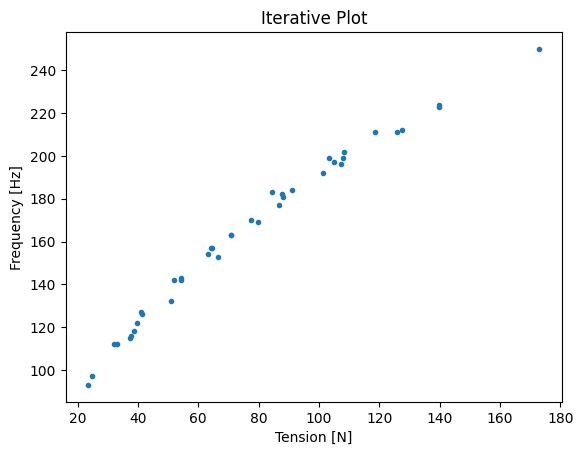

In [7]:
#Iterative plot
plt.figure()
plt.title("Iterative Plot")
plt.plot(Tension,Freq,".")
plt.xlabel("Tension [N]")
plt.ylabel("Frequency [Hz]")
plt.show()

# Data Analysis

**Part 1: Uncertainties**

In [ ]:
#calculate uncertainties using calculus approach

def u_freq(T,unc_T,L,unc_L,mu,unc_mu):
    df_dT = 1/(4*L*np.sqrt(mu*T))
    df_dL = -1/(2*L**2) * np.sqrt(T/mu)
    df_dmu = -np.sqrt(T)/(4*L*(mu)**(3/2))

    term_T = (df_dT*unc_T)**2
    term_L = (df_dL*unc_L)**2
    term_mu = (df_dmu*unc_mu)**2

    return np.sqrt(term_T + term_L + term_mu)

def u_Tension(r_mass,unc_r,theta_mass,unc_theta,r_wire):
    dT_drmass = m*g*np.sin(theta_mass)/(r_wire*np.sin(theta_wire))
    dT_dthetamass = m*g*r_mass*np.cos(theta_mass)/(r_wire*np.sin(theta_wire))
    dT_drwire = -1*m*g*r_mass*np.sin(theta_mass)/(r_wire**2 * np.sin(theta_wire))

    term_rmass = (dT_drmass*unc_r)**2
    term_thetamass = (dT_dthetamass*unc_theta)**2
    term_rwire = (dT_drwire*unc_r)**2

    return np.sqrt(term_rmass + term_rwire + term_thetamass)

def u_mu(m_wire,u_mwire,l,u_l):
    dmu_dm = 1/l
    dmu_dl = -1*m_wire/(l**2)

    term_m = (dmu_dm *u_mwire)**2
    term_l = (dmu_dl *u_l)**2

    return np.sqrt(term_m + term_l)

**Part 2: fitting and plotting**

In [9]:
from scipy.optimize import curve_fit

In [10]:
#log of variables
log_Tension = np.log(Tension)
log_Freq = np.log(Freq)

def fit_func(log_T,b,c): #linear fit function y = const + b*log(T)
    return c + b*(log_T)

#fitting a linear function to log() of our data
popt,pcov = curve_fit(fit_func,log_Tension,log_Freq) 

b,c = popt

unc_b = np.sqrt(pcov[0,0])

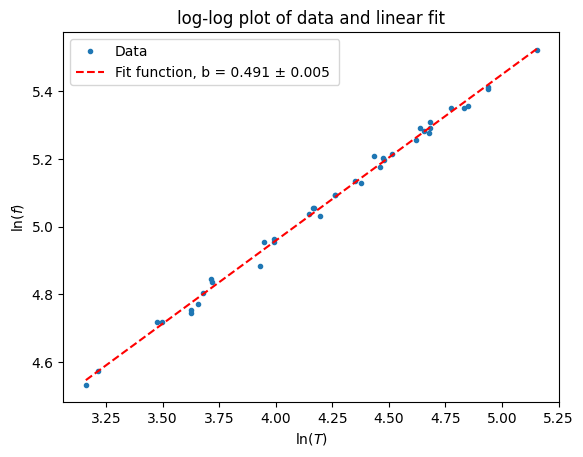

In [11]:
#Defining fit variables to plot the fitted line
log_T_fit = np.linspace(np.min(log_Tension),np.max(log_Tension),1000)
log_Freq_fit = fit_func(log_T_fit,*popt)

#plotting the fitted line
plt.figure()
plt.title("log-log plot of data and linear fit")
plt.plot(log_Tension, log_Freq, ".",label="Data")
plt.plot(log_T_fit,log_Freq_fit, "r--",label=f"Fit function, b = {b:.3f} \u00B1 {unc_b:.3f} ")
plt.xlabel(r"$\ln(T)$")
plt.ylabel(r"$\ln(f)$")
plt.legend()
plt.show()

In [12]:
#checking the power of b, theory: 1/2
print(f"The power of T is {b:.3f} \u00B1 {unc_b:.3f} ")

The power of T is 0.491 ± 0.005 


**Part 3: Theoretical fit and plotting uncertainties**

In [13]:
#calculate mu
d = 1e-3 #m
unc_d = 0.5e-3 #m

l = 116e-2 #m
unc_l = 0.05e-2 #m

m_wire = 3.9e-3 #kg
unc_mwire = 0.05e-3 #kg

mu = m_wire/l


In [14]:
#Theoretical fit taken with n=1
def theory_fit(T,mu):
    return np.sqrt(T/mu)*1/(2*L) 

T_theor = np.linspace(np.min(Tension),np.max(Tension),1000)
freq_theor = theory_fit(T_theor,mu)


In [15]:
#uncertainties for errorbarplot

unc_Tension = u_Tension(r_mass,r_u,theta_mass,theta_u,r_wire)
unc_mu = u_mu(m_wire,unc_mwire,l,unc_l)

unc_freq = u_freq(Tension,unc_Tension,L,L_u,mu,unc_mu)


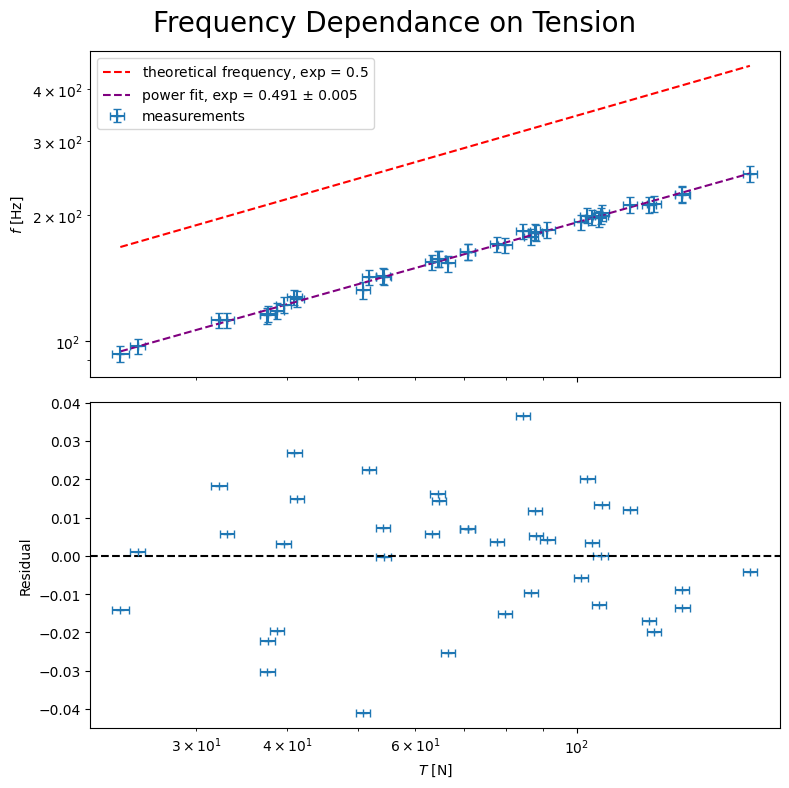

In [16]:
#full plot with data points, uncertainty, fitted line, theoretical fit and resiudals

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)
fig.suptitle("Frequency Dependance on Tension",fontsize=20)
# -------------------------
# Top: log-log plot
# -------------------------

ax1.errorbar(
    Tension,
    Freq,
    xerr=unc_Tension,
    yerr=unc_freq,
    fmt="+",
    capsize=3,
    label="measurements"
)

# Theoretical prediction
ax1.plot(
    T_theor,
    freq_theor,
    "r--",
    label=r"theoretical frequency, exp = $0.5$"
)

# Experimental power-law fit
ax1.plot(
    np.exp(log_T_fit),
    np.exp(log_Freq_fit),
    c="purple",
    linestyle="--",
    label=f"power fit, exp = {b:.3f} ± {unc_b:.3f}"
)

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_ylabel(r"$f$ [Hz]")
ax1.legend()

ax1.set_xlim(min(Tension) / 1.1, max(Tension) * 1.1)


# -------------------------
# Bottom: residuals
# -------------------------

# Calculate fitted frequency at the actual measurement points
log_Freq_fit_data = c + b * np.log(Tension)

# Residuals in log-space
residuals = log_Freq - log_Freq_fit_data

ax2.errorbar(
    Tension,
    residuals,
    xerr=unc_Tension,
    fmt="+",
    capsize=3
)

# Zero line
ax2.axhline(0, color="black", linestyle="--")

ax2.set_xscale("log")

ax2.set_xlabel(r"$T$ [N]")
ax2.set_ylabel("Residual")

plt.tight_layout()

#saving the figure
fig.savefig("frequency_dependance_on_tension.pdf",dpi=450,bbox_inches="tight")
plt.show()

**part 4: uncertainty analysis of exponent**


In [17]:
difference = 1/2 - b #theoretical power minus experimental power
unc_diff = unc_b #the uncertainty of the theoretical power is zero, so it comes down to the uncertainty of the experimetn

if (abs(difference) < 2*unc_diff):
    print("The experimental power is in accordance with the theoretical power of the tension T.")
else: 
    print("The experimental power is NOT accordance with the theoretical power of the tension T.")


The experimental power is in accordance with the theoretical power of the tension T.


From this plot it is clear that the theoretical frequency is a factor $\alpha$ greater than our measured frequency. There can be several causes:  
- Due to friction, the tension that was effective on our wire is smaller than the one calculated, resulting in a smaller frequency measured.  
- The wire length was measured too big, or the effective length is smaller.  
- It is not probable we measured an overtone, since then our frequency should be greater than the one in the theory. 

However, as expected, the exponent in the power relation is in accordance with the theory. 

# Notes 
- Make other fit to extraxt mass density mu
- Compare literature values with this extracted value mu
- Next time: measure frequency in more significant numbers  

- metal wire diameter = 1 mm +/- 0.5 mm
- mass of piece of metal wire = 3.9 g +/- 0.5 g
- length of metal wire = 116 cm +/- 0.05 cm 

- Add uncertainties